# K-Nearest Neighbors for weather risk 

Multidimesnional K-nn classifier to determine if certain weather is safe/unsafe for planes to fly through

## Do these in order 
1. Balance dataset 
2. Training/testing split 
3. Normalizing 
4. Wrap KNN in KNeighborsClassifier(n_neighbors=5) ? maybe tune value of n later?  
5. Fit the model to the x_train and y_train ( these come from the normalized data)
6. Get/visualzie predictions(Can use MatPlotLib for this) - also print out accuracy of model to see if we cna fine tune 
7. (if we have time) - use predict_proba to convert the binary safe/unsafe tags into actual weather risk. 
8. Pass back this weather risk into calcuations.py file 

## 0. Imports

Uncomment or add any extra imports you need.

In [1]:
%pip install numpy pandas scikit-learn matplotlib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Balance Dataset


In [3]:
import csv

unsafe_weather_data = []
safe_weather_data = []

unsafe_weather_count = 0
safe_weather_count = 0

#Pass 1: get safe & unsafe weather count & store all unsafe weather data in an array
with open('ml_ready_dataset.csv', 'r', newline='') as csvfile:
    reader = csv.DictReader(csvfile)

    for row in reader:
        if row['unsafe_weather'] == '1':
            unsafe_weather_count += 1
            unsafe_weather_data.append(row)
        if row['unsafe_weather'] == '0':
            safe_weather_count += 1


n = int(safe_weather_count / unsafe_weather_count)


#pass 2: store every nth safe weather data in an array until its the same length as unsafe array
cnt = 0

with open('ml_ready_dataset.csv', 'r', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if len(safe_weather_data) == len(unsafe_weather_data):
            break
        if row['unsafe_weather'] == '0':
            cnt += 1
            if cnt == n:
                safe_weather_data.append(row)
                cnt = 0


#write the balanced dataset to a new csv file
with open('balanced_ml_ready_dataset.csv', 'w', newline='') as csvfile:
    fieldnames = ['max_temp_f', 'min_temp_f', 'temp_range_f', 'max_dewpoint_f', 'min_dewpoint_f', 'dewpoint_range_f', 'precip_in', 'avg_wind_speed_kts', 'snow_in', 'avg_feel', 'icing_risk', 'has_snow', 'has_precip', 'high_wind', 'below_freezing', 'MONTH', 'DEP_1hrpre_num', 'DEP_1hrpost_num', 'unsafe_weather', 'FL_DATE', 'ORIGIN', 'DEST', 'MKT_CARRIER']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for row in unsafe_weather_data:
        writer.writerow(row)
    for row in safe_weather_data:
        writer.writerow(row)


## 1. Configuration and loading data

**TODO:** Set `CSV_PATH` to balanced or raw dataset. Run `ml_dataset_scripts.py` from this folder first if you need to inspect counts; export a balanced CSV.

In [4]:
# Path relative to this notebook (usually backend/calculations)
CSV_PATH = Path("balanced_ml_ready_dataset.csv")
#print(Path("ml_ready_dataset (1).csv"))


#If the file is missing, create a tiny synthetic dataset 
if not CSV_PATH.is_file():
    print(f"Warning: {CSV_PATH} not found. Using synthetic data for pipeline practice.")
    rng = np.random.default_rng(42)
    n = 50000
    df = pd.DataFrame(
        {
            "wind_speed": rng.lognormal(3, 0.5, n),
            "wind_gust": rng.lognormal(3.2, 0.5, n),
            "precip_inches": rng.exponential(0.1, n),
            "humidity_pct": rng.uniform(20, 100, n),
            "lightning_strikes_10mi": rng.poisson(2, n),
            "unsafe_weather": rng.choice([0, 1], n, p=[0.85, 0.15]),
        }
    )
else:

    df = pd.read_csv(CSV_PATH)


print(df.shape)
print(df.dtypes)
df.head()

(95692, 23)
max_temp_f            float64
min_temp_f            float64
temp_range_f          float64
max_dewpoint_f        float64
min_dewpoint_f        float64
dewpoint_range_f      float64
precip_in             float64
avg_wind_speed_kts    float64
snow_in               float64
avg_feel              float64
icing_risk              int64
has_snow                int64
has_precip              int64
high_wind               int64
below_freezing          int64
MONTH                   int64
DEP_1hrpre_num        float64
DEP_1hrpost_num       float64
unsafe_weather          int64
FL_DATE                   str
ORIGIN                    str
DEST                      str
MKT_CARRIER               str
dtype: object


,max_temp_f,min_temp_f,temp_range_f,max_dewpoint_f,min_dewpoint_f,dewpoint_range_f,precip_in,avg_wind_speed_kts,snow_in,avg_feel,...,high_wind,below_freezing,MONTH,DEP_1hrpre_num,DEP_1hrpost_num,unsafe_weather,FL_DATE,ORIGIN,DEST,MKT_CARRIER
0,57.0,47.0,10.0,50.0,44.1,5.900002,1.8800,12.860848,0.0,49.052990,...,0,0,4,18.0,13.0,1,2023-04-06,AUS,SRQ,G4
1,50.0,46.0,4.0,45.0,41.0,4.000000,0.2200,12.078770,0.0,42.358143,...,0,0,4,13.0,16.0,1,2023-04-22,BOS,SRQ,G4
2,89.0,67.0,22.0,66.0,60.1,5.900002,0.0000,3.731915,0.0,79.801140,...,0,0,6,3.0,2.0,1,2023-06-23,MEM,SFB,G4
3,90.0,69.0,21.0,71.1,66.0,5.099998,0.0001,6.256629,0.0,82.591330,...,0,0,7,11.0,3.0,1,2023-07-05,IND,SFB,G4
4,116.0,93.0,23.0,64.0,52.0,12.000000,0.0000,7.386298,0.0,105.166150,...,0,0,7,24.0,33.0,1,2023-07-28,PHX,AVL,G4


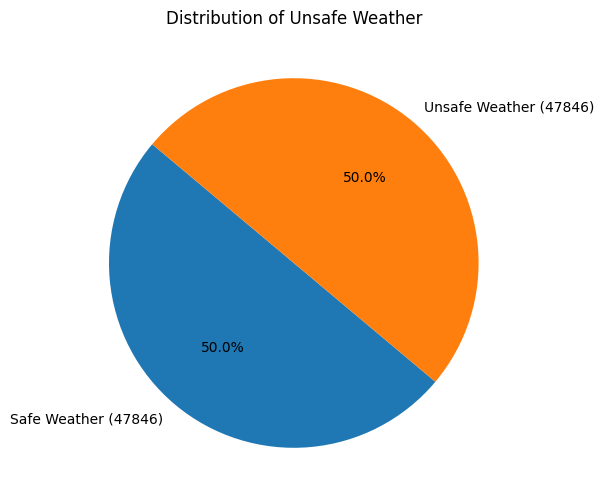

In [5]:
#pie chart for unsafe weather
import matplotlib.pyplot as plt
counts = df["unsafe_weather"].value_counts()
labels = ["Safe Weather (" + str(int(counts[0])) + ")", "Unsafe Weather (" + str(int(counts[1])) + ")"]
sizes = counts.values
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Unsafe Weather")
plt.show()

### Split Data

In [6]:
# Split data here for training/testing - 80 -20 split 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data = df.drop(columns=['FL_DATE', 'ORIGIN', 'DEST', 'MKT_CARRIER'], errors='ignore')

# change to columns we want to use to train the data 
X = data.drop(columns=['unsafe_weather']) 

# change to the unsafe_weather/safe weather 
y = data['unsafe_weather']   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # tune later, but for now it is 80-20

print(X_test[0:5])
print(y)

       max_temp_f  min_temp_f  temp_range_f  max_dewpoint_f  min_dewpoint_f  \
65657        74.0        54.0          20.0            51.1            48.0   
87881        80.0        68.0          12.0            71.0            66.2   
66850        40.0        25.0          15.0            16.0            10.0   
45068        90.0        67.0          23.0            72.0            62.1   
79407        74.0        53.0          21.0            61.0            53.0   

       dewpoint_range_f  precip_in  avg_wind_speed_kts  snow_in   avg_feel  \
65657          3.099998     0.0000            5.474550   0.0000  62.765575   
87881          4.800003     2.5400            9.645637   0.0000  73.060630   
66850          6.000000     0.0001            5.822141   0.0001  24.566692   
45068          9.900002     0.0400            4.257984   0.0000  77.638306   
79407          8.000000     0.0000            3.736598   0.0000  63.763763   

       icing_risk  has_snow  has_precip  high_wind  belo

### KNN Pipeline(Normalizing + fitiing to classifier)


In [7]:
# Adding normalizing 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

weather_knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),   
    ('knn', KNeighborsClassifier(n_neighbors=5))
])


weather_knn_pipeline.fit(X_train, y_train) # All column data is now normalized. 

# Same check you had before
for i in range(0, 99):
    print(weather_knn_pipeline.predict([X_test.iloc[i]]), y_test.iloc[i])


c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


[0] 0
[1] 0
[0] 0
[1] 1
[1] 0
[0] 0
[1] 1
[0] 0
[0] 1
[1] 1
[0] 0
[0] 0
[0] 0
[0] 0
[1] 0
[0] 0
[0] 1
[1] 0
[0] 0
[0] 1
[1] 1
[1] 0
[1] 0
[0] 1
[1] 1
[1] 1
[1] 1
[1] 1
[0] 0
[0] 0
[0] 1
[1] 1
[1] 1
[0] 0
[0] 0
[1] 1
[0] 0
[1] 1
[1] 1
[1] 1
[1] 1
[1] 1
[0] 0
[1] 0
[1] 0
[1] 0
[1] 1
[1] 1
[0] 1
[1] 0
[1] 1
[0] 0
[0] 0
[1] 1
[0] 0
[0] 1
[1] 1
[0] 1
[1] 0
[1] 1
[0] 0
[1] 1


c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarni

[0] 0
[1] 1
[0] 0
[1] 1
[0] 0
[1] 0
[1] 1
[0] 0
[0] 1
[1] 1
[1] 0
[0] 0
[1] 1
[0] 0
[1] 1
[0] 0
[0] 1
[0] 0
[0] 0
[1] 1
[1] 1
[0] 0
[1] 0
[0] 0
[0] 0
[0] 0
[0] 0
[1] 1
[1] 1
[1] 0
[1] 1
[0] 0
[0] 0
[0] 0
[0] 1
[1] 0
[0] 0


c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\SRIDH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarni

##### Visualization of Accuracy/Confusion Matrix to tune above


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Make predictions on test data
y_pred = weather_knn_pipeline.predict(X_test)

# 2. Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 3. Display matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=weather_knn_pipeline.classes_)
print((cm[0,0] + cm[1,1]) / cm.sum())

# visualize confusion matrix
disp.plot()
plt.show()

[[7748 1774]
 [1928 7689]]
0.806572966194681


In [ ]:
# classification report
from sklearn.metrics import classification_report
# don't remember if you need target name - that is just the classes (safe v unsafe)
print(classification_report(y_test, y_pred))

### Adding a way to save the model and run it from another file

In [ ]:
# Save trained KNN pipeline for the cost function
# It should include scaling + the KNN classifier)
from pathlib import Path
import joblib

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODELS_DIR / "weather_knn.joblib"
joblib.dump(weather_knn_pipeline, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH.resolve()}")


Saved model to: C:\Users\SRIDH\Projects\teamtech25-26\backend\calculations\models\weather_knn.joblib
